# SMART ENERGY MONITORING SYSTEM

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
# LOAD DATASET

df = pd.read_csv('sensor_data.csv')

print(df.head())


                created_at  entry_id  field1  field2  field3  field4
0  2026-05-16 18:56:08 UTC         1    24.0    40.0       0    1179
1  2026-05-16 18:57:13 UTC         2    24.0    40.0       0    1179
2  2026-05-16 18:58:15 UTC         3    24.0    40.0       0    1179
3  2026-05-16 19:01:11 UTC         4    24.0    40.0       0    1179
4  2026-05-16 19:01:27 UTC         5    24.0    40.0       0    2404


In [3]:
# RENAME COLUMNS

df.rename(columns={
    'field1': 'Temperature',
    'field2': 'Humidity',
    'field3': 'Motion',
    'field4': 'Light'
}, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   created_at   30 non-null     object 
 1   entry_id     30 non-null     int64  
 2   Temperature  30 non-null     float64
 3   Humidity     30 non-null     float64
 4   Motion       30 non-null     int64  
 5   Light        30 non-null     int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1.5+ KB


In [10]:
# REMOVE UNNECESSARY COLUMNS

df = df[['Temperature', 'Humidity', 'Motion', 'Light']]

In [11]:
print('Necessary columns \n')
print(df.info())

Necessary columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  30 non-null     float64
 1   Humidity     30 non-null     float64
 2   Motion       30 non-null     int64  
 3   Light        30 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 1.1 KB
None


In [12]:
# HANDLE MISSING VALUES

df.dropna(inplace=True)

In [13]:
# CONVERT DATA TYPES
df['Temperature'] = df['Temperature'].astype(float)
df['Humidity'] = df['Humidity'].astype(float)
df['Motion'] = df['Motion'].astype(int)
df['Light'] = df['Light'].astype(float)

In [14]:
# CREATE TARGET LABEL

def energy_label(row):

    if row['Motion'] == 1 and row['Light'] < 1500:
        return 'Occupied'

    elif row['Motion'] == 0 and row['Light'] > 1500:
        return 'Energy Saving'

    else:
        return 'High Usage'

df['Status'] = df.apply(energy_label, axis=1)

In [15]:
# DISPLAY DATA

print(df.head())

   Temperature  Humidity  Motion   Light         Status
0         24.0      40.0       0  1179.0     High Usage
1         24.0      40.0       0  1179.0     High Usage
2         24.0      40.0       0  1179.0     High Usage
3         24.0      40.0       0  1179.0     High Usage
4         24.0      40.0       0  2404.0  Energy Saving


In [16]:
# FEATURES & TARGET

X = df[['Temperature', 'Humidity', 'Motion', 'Light']]

y = df['Status']

In [17]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
# RANDOM FOREST MODEL

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
# PREDICTIONS

y_pred = model.predict(X_test)


In [20]:
# ACCURACY
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)


Accuracy Score:
1.0


In [21]:
# CLASSIFICATION REPORT

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

Energy Saving       1.00      1.00      1.00         1
   High Usage       1.00      1.00      1.00         5

     accuracy                           1.00         6
    macro avg       1.00      1.00      1.00         6
 weighted avg       1.00      1.00      1.00         6



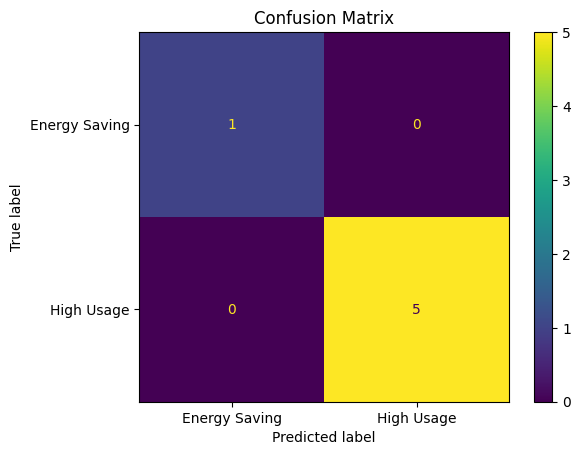

In [23]:
# CONFUSION MATRIX

labels = np.unique(y_pred)

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

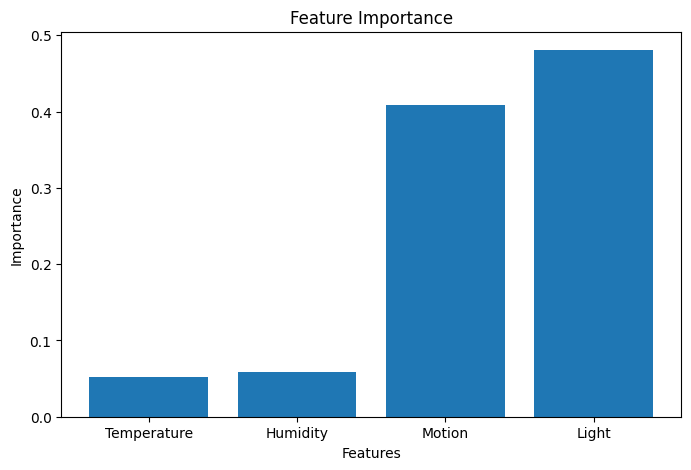

In [24]:
# FEATURE IMPORTANCE

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()


In [26]:
# SAMPLE PREDICTION

sample = pd.DataFrame(
    [[30, 55, 1, 900]],
    columns=['Temperature', 'Humidity', 'Motion', 'Light']
)

prediction = model.predict(sample)

print("\nSample Prediction:")
print(prediction)


Sample Prediction:
['Occupied']
